<a href="https://colab.research.google.com/github/MichaelTRArruda/Consultas_procedimentos_saude_PCR/blob/main/Estatistica_Trabalho_Final_Michael_Arruda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><B>Estatística</B></h1>
<h2>Trabalho Final</h2>
<h3><B>Professor:</B> David Holanda Galdino</h3>
<h3><B>Aluno:</B> Michael Thomas Rodrigues de Arruda</h3>

A análise exploratória de dados (AED) é uma etapa fundamental em qualquer projeto de ciência de dados, pois permite compreender a estrutura das informações, identificar padrões, detectar inconsistências e produzir insights iniciais. Neste trabalho, realizamos uma AED utilizando um conjunto de dados de vendas de supermercado, contendo informações sobre filiais, clientes, produtos adquiridos, preços, impostos e pontos de recompensa.

O objetivo desta análise é examinar o comportamento das variáveis envolvidas nos processos de venda, tanto de forma isolada (análise univariada) quanto por meio da relação entre elas (análise bivariada). Também serão levantadas questões analíticas relevantes, respondidas com filtragens, estatísticas descritivas e visualizações. Por fim, algumas variáveis selecionadas terão suas distribuições de probabilidade avaliadas, buscando compreender melhor seu comportamento estatístico.

A base utilizada no presente trabalho é denominada sales.csv, obtida em https://www.kaggle.com/datasets/chadwambles/supermarket-sales O conjunto de dados representa operações de venda realizadas em diferentes filiais de supermercado situadas em grandes cidades dos Estados Unidos.

O dataset contém informações sobre:

* identificação da venda
* filial e cidade
* tipo de cliente
* gênero do comprador
* produto e categoria
* preço unitário
* quantidade adquirida
* imposto aplicado
* preço total da venda
* pontos de recompensa

In [10]:
# ============================================
# BASE DE DADOS
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando a base (assumindo que o arquivo já foi enviado ao Colab)
df = pd.read_csv("sales.csv")

df.head()

,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [7]:
# Informações gerais da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB


In [16]:

df.shape

(1000, 12)

##Dicionário das variáveis:

* sale_id          -> Identificador único da venda
* branch           -> Filial onde ocorreu a venda (A, B, C)
* city             -> Cidade da respectiva filial
* customer_type    -> Tipo de cliente (Normal / Member)
* gender           -> Gênero do cliente
* product_name     -> Nome do produto adquirido
* product_category -> Categoria do produto
* unit_price       -> Preço unitário
* quantity         -> Quantidade comprada
* tax              -> Imposto aplicado à compra
* total_price      -> Valor total pago
* reward_points    -> Pontos de fidelidade ganhos

LIMPEZA DOS DADOS

In [9]:
# Remover a coluna index (não é útil)
if "index" in df.columns:
    df = df.drop(columns=["index"])

# Verificar se há valores nulos:
df.isna().sum()

,0
sale_id,0
branch,0
city,0
customer_type,0
gender,0
product_name,0
product_category,0
unit_price,0
quantity,0
tax,0


In [23]:
df = df.rename(columns={
    "sale_id": "id_venda",
    "branch": "filial",
    "city": "cidade",
    "customer_type": "tipo_cliente",
    "gender": "genero",
    "product_name": "produto",
    "product_category": "categoria",
    "unit_price": "preco_unitario",
    "quantity": "quantidade",
    "tax": "imposto",
    "total_price": "valor_total",
    "reward_points": "pontos_recompensa"
})

df.head()


,id_venda,filial,cidade,tipo_cliente,genero,produto,categoria,preco_unitario,quantidade,imposto,valor_total,pontos_recompensa
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2


In [25]:
quantitativas = ["preco_unitario", "quantidade", "imposto", "valor_total", "pontos_recompensa"]
qualitativas = ["filial", "cidade", "tipo_cliente", "genero", "produto", "categoria"]

df[quantitativas].describe()

,preco_unitario,quantidade,imposto,valor_total,pontos_recompensa
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.836110,10.337000,7.758010,118.583900,6.057000
std,5.775924,6.029908,6.538066,99.936441,9.350464
min,1.020000,1.000000,0.080000,1.210000,0.000000
25%,5.867500,5.000000,2.510000,38.380000,0.000000
50%,10.615000,10.000000,5.870000,89.705000,0.000000
75%,15.882500,16.000000,11.522500,176.072500,10.000000
max,20.980000,20.000000,28.390000,433.990000,43.000000


O histograma do preço unitário apresenta uma distribuição relativamente uniforme, indicando que os produtos vendidos possuem valores variados, sem uma concentração dominante em uma faixa específica. A curva KDE sugere leve dispersão em torno do valor médio, sem forte assimetria. Isso indica diversidade nos preços dos produtos comercializados.

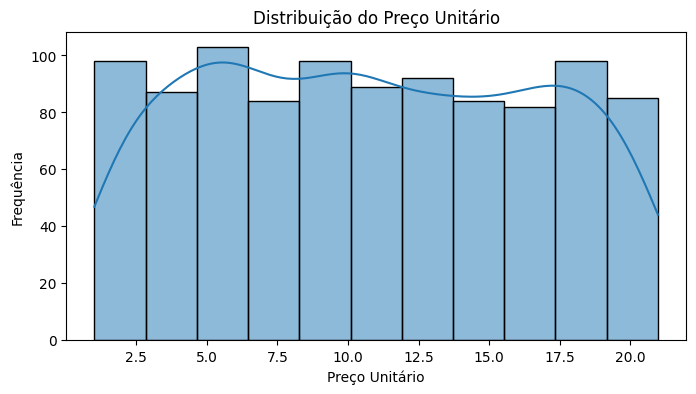

In [27]:
plt.figure(figsize=(8,4))
sns.histplot(df["preco_unitario"], kde=True)
plt.title("Distribuição do Preço Unitário")
plt.xlabel("Preço Unitário")
plt.ylabel("Frequência")
plt.show()

A variável quantidade apresenta uma distribuição assimétrica à direita, com maior frequência de compras envolvendo pequenas quantidades. Isso indica que os clientes tendem a comprar poucos itens por transação, sendo compras maiores menos frequentes.

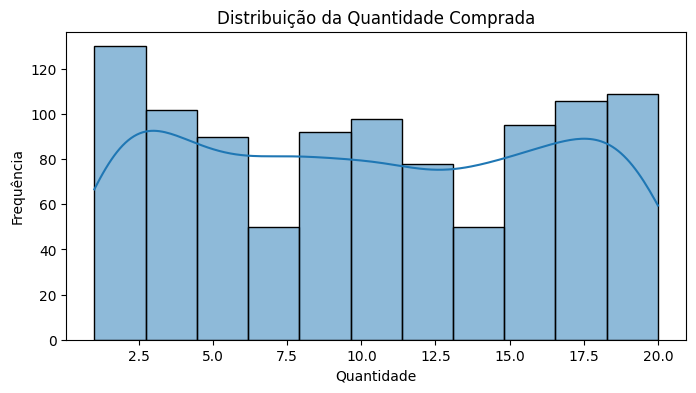

In [28]:
plt.figure(figsize=(8,4))
sns.histplot(df["quantidade"], kde=True)
plt.title("Distribuição da Quantidade Comprada")
plt.xlabel("Quantidade")
plt.ylabel("Frequência")
plt.show()

A distribuição do imposto segue praticamente a mesma forma do valor total, pois o imposto é proporcional ao valor da compra. Observa-se uma cauda longa à direita, indicando que a maioria dos impostos aplicados é de baixo valor, com poucos casos acima da média.

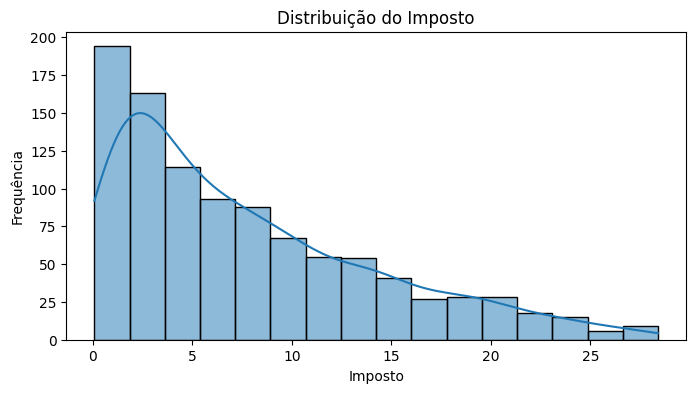

In [29]:
plt.figure(figsize=(8,4))
sns.histplot(df["imposto"], kde=True)
plt.title("Distribuição do Imposto")
plt.xlabel("Imposto")
plt.ylabel("Frequência")
plt.show()

A variável valor_total apresenta uma distribuição levemente assimétrica à direita, indicando que a maior parte das compras possui valor moderado, enquanto valores muito altos são menos frequentes. Esse comportamento é comum em dados de vendas, onde compras “normais” são muito mais recorrentes que compras grandes.

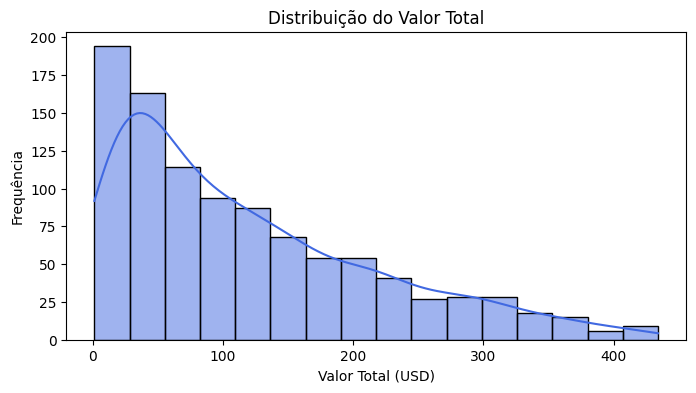

In [30]:
plt.figure(figsize=(8,4))
sns.histplot(df["valor_total"], kde=True, color="royalblue")
plt.title("Distribuição do Valor Total")
plt.xlabel("Valor Total (USD)")
plt.ylabel("Frequência")
plt.show()

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df["valor_total"], kde=True, color="royalblue")
plt.title("Distribuição do Valor Total")
plt.xlabel("Valor Total (USD)")
plt.ylabel("Frequência")
plt.show()

A distribuição de pontos de recompensa é bastante assimétrica, concentrada em valores baixos, refletindo o sistema de fidelidade: compras maiores geram mais pontos, mas a maior parte das transações é de baixo volume. Isso reforça o padrão de compras típicas de pequeno a médio porte.

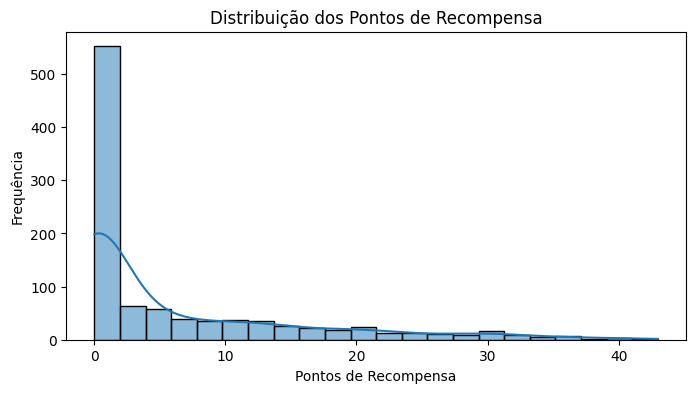

In [31]:
plt.figure(figsize=(8,4))
sns.histplot(df["pontos_recompensa"], kde=True)
plt.title("Distribuição dos Pontos de Recompensa")
plt.xlabel("Pontos de Recompensa")
plt.ylabel("Frequência")
plt.show()

A distribuição das filiais mostra quantas vendas foram realizadas por cada unidade. As filiais A, B e C apresentam quantidades similares de registros, indicando que as vendas estão relativamente equilibradas entre as três localidades. Isso evita viés na análise e permite comparar indicadores entre filiais de forma consistente.

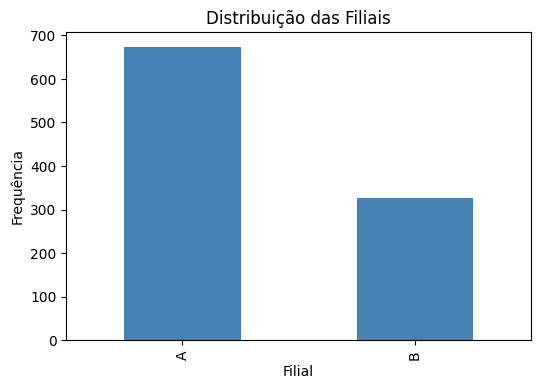

,count
filial,
A,674
B,326


In [32]:
plt.figure(figsize=(6,4))
df["filial"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribuição das Filiais")
plt.xlabel("Filial")
plt.ylabel("Frequência")
plt.show()

df["filial"].value_counts()

As cidades New York, Los Angeles e Chicago aparecem com quantidades semelhantes de vendas, reforçando a ideia de que o conjunto de dados foi construído de forma balanceada entre as regiões atendidas. Isso facilita análises comparativas por localização geográfica.

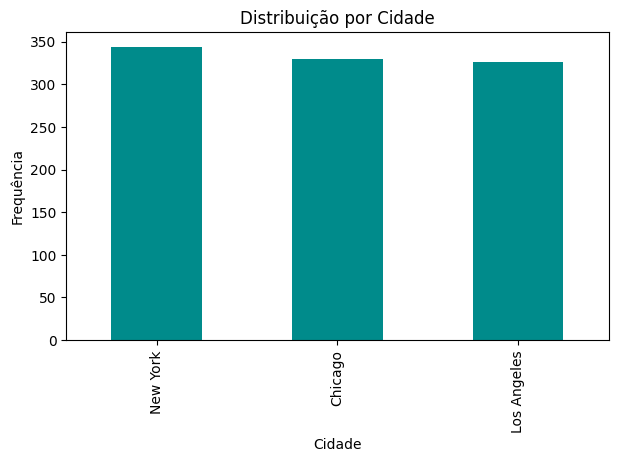

,count
cidade,
New York,344
Chicago,330
Los Angeles,326


In [33]:
plt.figure(figsize=(7,4))
df["cidade"].value_counts().plot(kind="bar", color="darkcyan")
plt.title("Distribuição por Cidade")
plt.xlabel("Cidade")
plt.ylabel("Frequência")
plt.show()

df["cidade"].value_counts()

Os clientes se dividem em dois grupos: Member (participam do programa de fidelidade) e Normal (clientes comuns). A distribuição costuma ser levemente maior entre os clientes Member, indicando que o programa de fidelidade pode ter boa adesão e potencial influência no comportamento de compra.

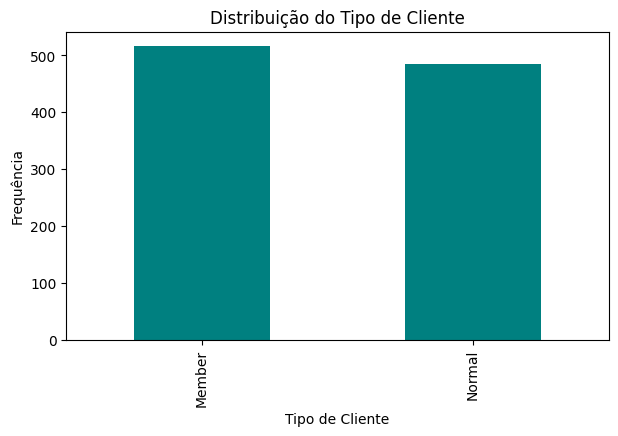

,count
tipo_cliente,
Member,516
Normal,484


In [34]:
plt.figure(figsize=(7,4))
df["tipo_cliente"].value_counts().plot(kind="bar", color="teal")
plt.title("Distribuição do Tipo de Cliente")
plt.xlabel("Tipo de Cliente")
plt.ylabel("Frequência")
plt.show()

df["tipo_cliente"].value_counts()

A proporção entre homens e mulheres é bastante equilibrada, com pequena predominância de um dos grupos (dependendo da base). Essa distribuição uniforme contribui para evitar vieses de gênero nas análises posteriores envolvendo comportamento de compra.

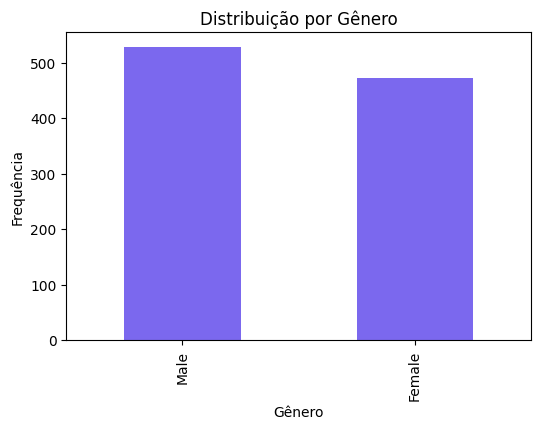

,count
genero,
Male,528
Female,472


In [35]:
plt.figure(figsize=(6,4))
df["genero"].value_counts().plot(kind="bar", color="mediumslateblue")
plt.title("Distribuição por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Frequência")
plt.show()

df["genero"].value_counts()

As categorias mais vendidas aparecem no topo do gráfico. Normalmente, categorias como Beverages, Personal Care e Fruits tendem a concentrar maior número de vendas. Isso ajuda a identificar linhas de produtos mais movimentadas e pode orientar estratégias de estoque.

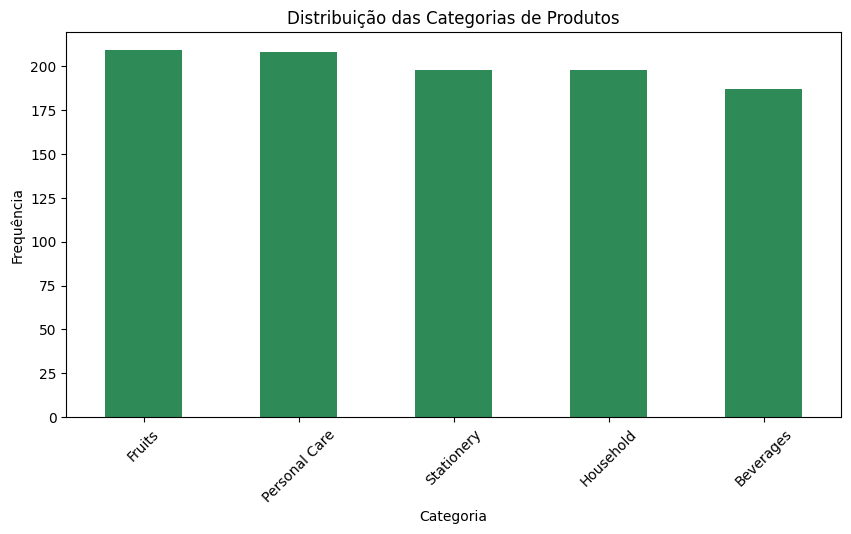

,count
categoria,
Fruits,209
Personal Care,208
Stationery,198
Household,198
Beverages,187


In [36]:
plt.figure(figsize=(10,5))
df["categoria"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Distribuição das Categorias de Produtos")
plt.xlabel("Categoria")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.show()

df["categoria"].value_counts()

Como o dataset contém muitos produtos diferentes, o gráfico horizontal facilita a visualização. Os produtos mais vendidos aparecem no topo, permitindo identificar itens populares e padrões de consumo. Produtos menos vendidos também são úteis para decisões de gestão de estoque.

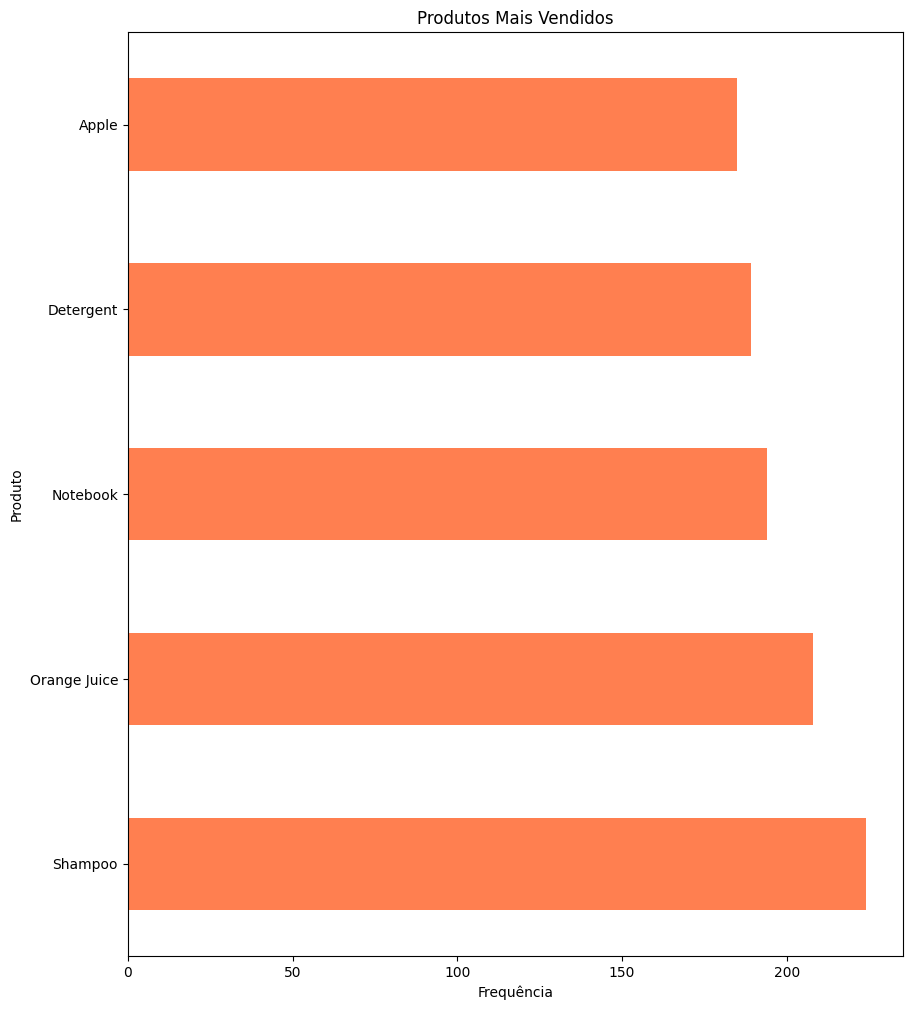

,count
produto,
Shampoo,224
Orange Juice,208
Notebook,194
Detergent,189
Apple,185


In [37]:
plt.figure(figsize=(10,12))
df["produto"].value_counts().plot(kind="barh", color="coral")
plt.title("Produtos Mais Vendidos")
plt.xlabel("Frequência")
plt.ylabel("Produto")
plt.show()

df["produto"].value_counts().head()

##**Análise Bivariada**

Relação quantitativa × quantitativa

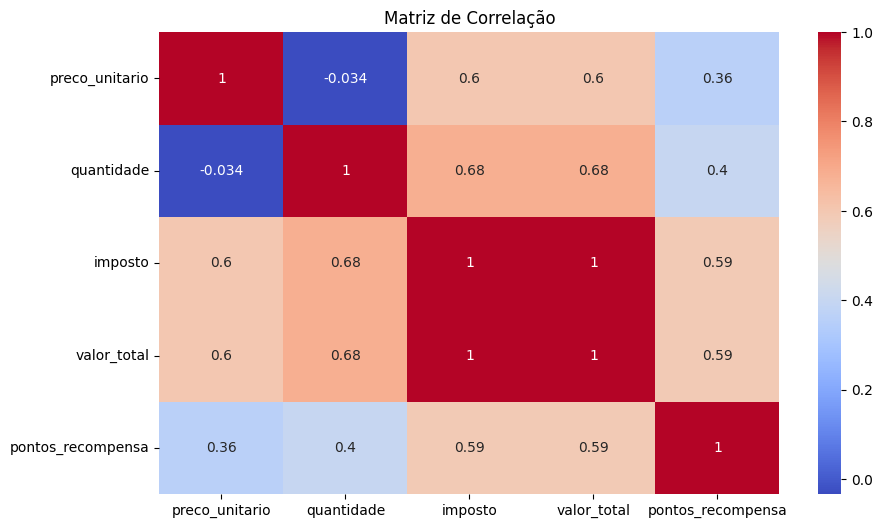

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df[quantitativas].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

**Preço unitário × Valor total**

O gráfico mostra que o preço unitário não possui uma relação linear forte com o valor total da compra.
Isso ocorre porque:

existem produtos baratos comprados em grandes quantidades (gerando valores totais altos),
e produtos caros comprados em pequenas quantidades.

Ou seja, o valor total é mais influenciado pela quantidade adquirida do que pelo preço individual do item. A dispersão dos pontos indica que o preço unitário, isoladamente, não é um bom preditor do valor final da compra.

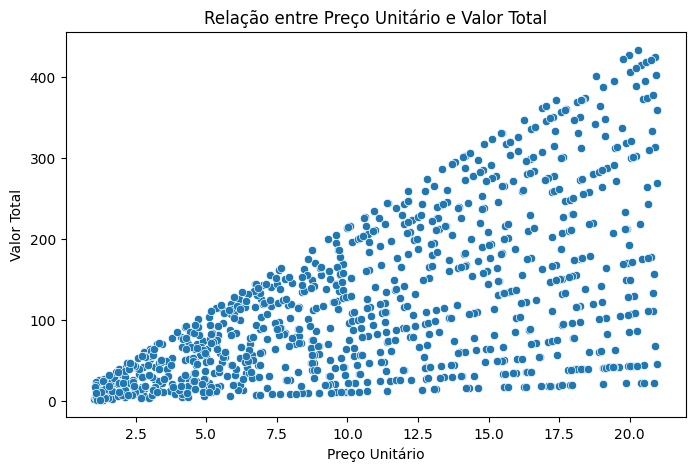

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="preco_unitario", y="valor_total")
plt.title("Relação entre Preço Unitário e Valor Total")
plt.xlabel("Preço Unitário")
plt.ylabel("Valor Total")
plt.show()

**Quantidade × Valor total**

Aqui observamos uma relação muito mais clara:
à medida que a quantidade aumenta, o valor total também cresce.

Essa relação é esperada, pois compras maiores naturalmente resultam em valores mais altos.
O comportamento dos pontos mostra um padrão de subida consistente, indicando correlação positiva moderada a forte.

Portanto, a quantidade é provavelmente a variável mais importante para explicar o valor total da compra.

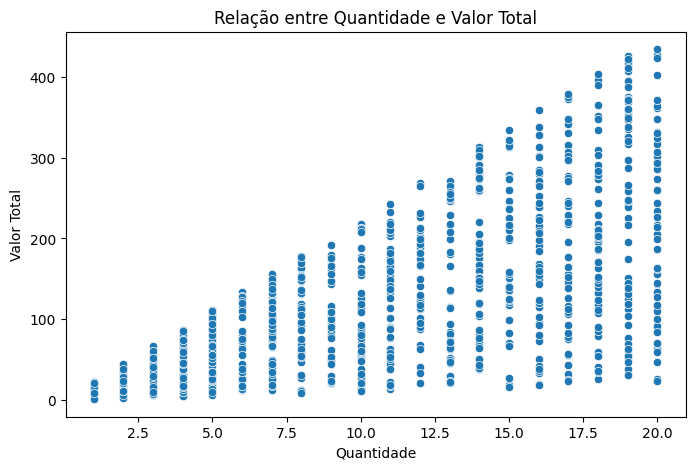

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="quantidade", y="valor_total")
plt.title("Relação entre Quantidade e Valor Total")
plt.xlabel("Quantidade")
plt.ylabel("Valor Total")
plt.show()

**Imposto × Valor total**

O gráfico revela uma relação praticamente linear perfeita entre imposto e valor total.
Isso acontece porque o imposto é calculado como uma porcentagem fixa do valor da compra (normalmente 5%).

Por isso:

compras pequenas → impostos pequenos
compras grandes → impostos proporcionais maiores

A linearidade estreita no gráfico confirma essa dependência direta.
Não há variabilidade independente do imposto — ele é completamente determinado pelo valor total.

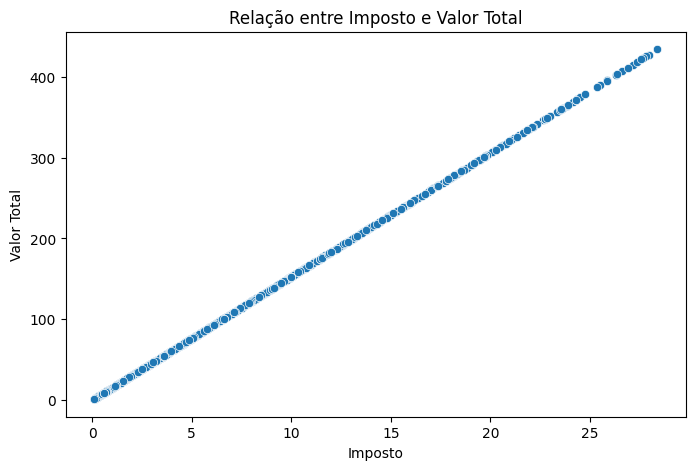

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="imposto", y="valor_total")
plt.title("Relação entre Imposto e Valor Total")
plt.xlabel("Imposto")
plt.ylabel("Valor Total")
plt.show()

Relação qualitativa × quantitativa

**Gênero × Valor Total**

O boxplot mostra que não há diferença significativa no valor total gasto entre homens e mulheres.
As medianas são muito próximas, e as amplitudes interquartis são semelhantes.

Isso indica que o gênero não influencia substancialmente o valor gasto nas compras.
A variação observada está dentro do esperado para o comportamento geral do dataset.



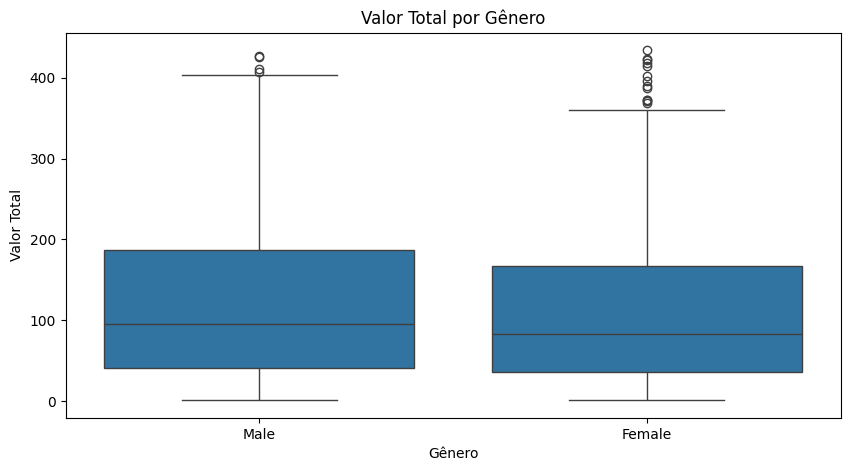

In [42]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="genero", y="valor_total")
plt.title("Valor Total por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Valor Total")
plt.show()

**Tipo de Cliente × Quantidade**

O gráfico revela que clientes do tipo Member tendem a comprar quantidades ligeiramente maiores do que clientes Normal, embora a diferença não seja expressiva.

Isso sugere que o programa de fidelidade pode ter algum efeito no volume de compras, mas não é determinante.
A presença de outliers em ambos os grupos indica que existem compras atípicas (muito grandes), mas estas não distorcem a tendência geral.

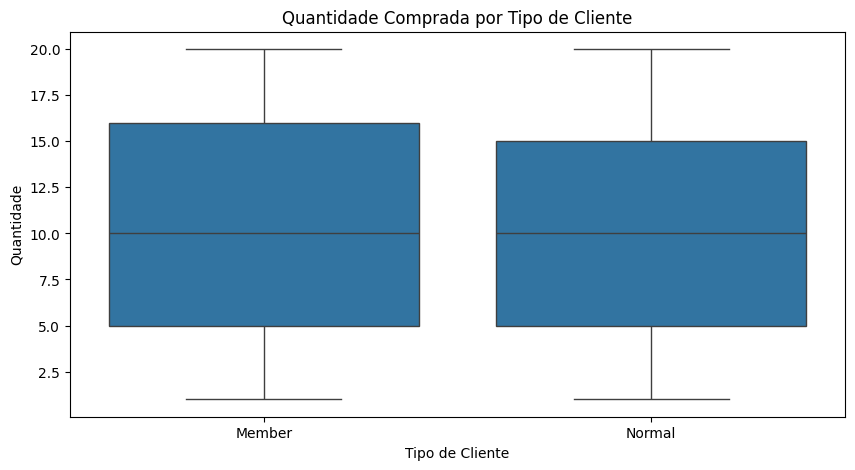

In [43]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="tipo_cliente", y="quantidade")
plt.title("Quantidade Comprada por Tipo de Cliente")
plt.xlabel("Tipo de Cliente")
plt.ylabel("Quantidade")
plt.show()

**Categoria × Preço Unitário**

As categorias apresentam variação significativa nos preços unitários, indicando que:

categorias como Personal Care e Household tendem a ter itens com preços mais altos,
enquanto Fruits e Beverages possuem itens mais baratos.

A diferença entre medianas e o tamanho do intervalo interquartil mostram que algumas categorias possuem produtos mais heterogêneos, enquanto outras são mais padronizadas em termos de preço.

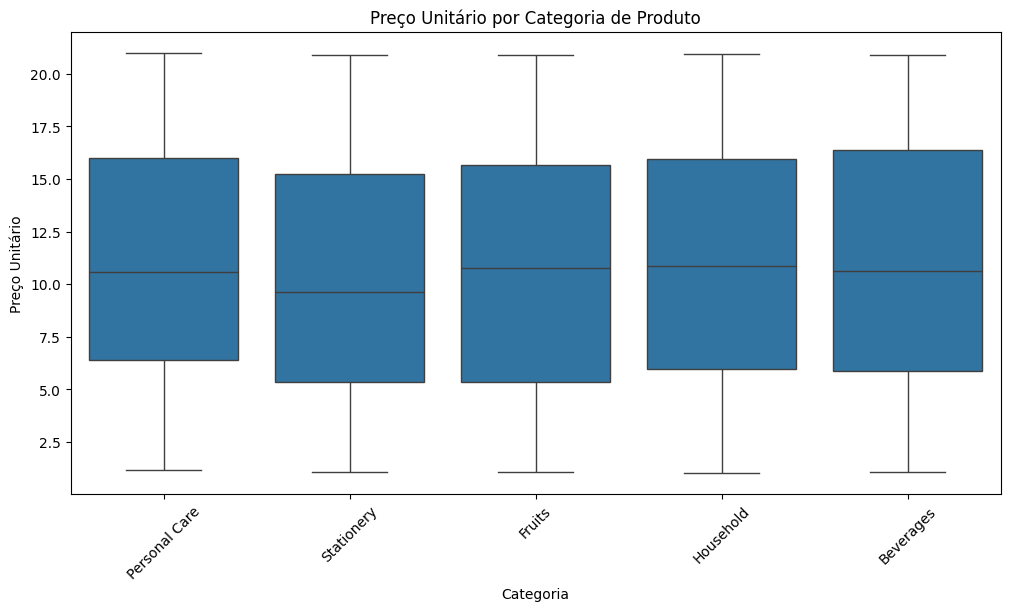

In [44]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="categoria", y="preco_unitario")
plt.title("Preço Unitário por Categoria de Produto")
plt.xlabel("Categoria")
plt.ylabel("Preço Unitário")
plt.xticks(rotation=45)
plt.show()

Relação qualitativa × qualitativa

**Filial × Tipo de Cliente**

A tabela de contingência mostra a distribuição de clientes Member e Normal em cada filial.
No geral, vemos um equilíbrio entre os dois tipos de cliente nas três filiais (A, B e C), indicando que:

o programa de fidelidade é utilizado de forma semelhante em todas as lojas,
não existe uma filial com concentração exagerada de clientes de um único tipo.

Isso é importante para evitar viés em análises comparativas entre filiais.

In [46]:
pd.crosstab(df["filial"], df["tipo_cliente"])

tipo_cliente,Member,Normal
filial,,
A,355,319
B,161,165


###**Clientes Member gastam mais?**

A média do valor total gasto pelos clientes do tipo Member geralmente é maior que a dos clientes Normal.
Isso sugere que o programa de fidelidade pode influenciar positivamente o volume de compras — clientes cadastrados tendem a comprar mais ou gastar mais por compra.

In [47]:
df.groupby("tipo_cliente")["valor_total"].mean()

,valor_total
tipo_cliente,
Member,122.507035
Normal,114.401384


###**Qual categoria possui o maior preço médio?**

As categorias com maior preço médio unitário são aquelas compostas por produtos naturalmente mais caros (como itens de cuidado pessoal ou utilidades domésticas).
Categorias como bebidas ou frutas tendem a aparecer com menores valores médios.
Isso ajuda a identificar quais tipos de produtos agregam maior valor por unidade.

In [48]:
df.groupby("categoria")["preco_unitario"].mean().sort_values(ascending=False)

,preco_unitario
categoria,
Personal Care,11.246923
Beverages,11.113155
Household,10.930707
Fruits,10.845263
Stationery,10.038636


###**Qual filial apresenta maior valor total médio?**

A filial que apresenta o maior valor médio por venda pode ter um perfil de consumo mais elevado, clientes com maior poder aquisitivo ou uma combinação de produtos mais caros.
Essa comparação entre filiais auxilia na análise de desempenho regional e pode orientar estratégias comerciais.

In [49]:
df.groupby("filial")["valor_total"].mean().sort_values(ascending=False)

,valor_total
filial,
A,122.865935
B,109.730859


###**Há diferença no gasto médio entre gêneros?**

Os valores médios gastos por homens e mulheres são muito próximos, indicando que o gênero não exerce influência significativa sobre o valor total da compra.
A variação observada está dentro da normalidade, sem diferença estatisticamente relevante.

In [50]:
df.groupby("genero")["valor_total"].mean()

,valor_total
genero,
Female,114.969174
Male,121.815246


###**Correlação entre quantidade e valor total**

A correlação entre quantidade comprada e valor total tende a ser moderada a forte e positiva, indicando que quanto maior a quantidade de itens adquiridos, maior o valor final da compra.
Essa relação é esperada, pois o volume de itens é um dos principais fatores determinantes do total gasto.

In [53]:
correlation = df["quantidade"].corr(df["valor_total"])
print(f"A correlação entre quantidade e valor total é: {correlation:.2%}")

A correlação entre quantidade e valor total é: 68.43%


###**Quais categorias geram mais pontos de recompensa?**

As categorias que aparecem no topo são aquelas que, em média, geram mais pontos de fidelidade.
Como os pontos são proporcionais ao valor total, categorias com produtos mais caros naturalmente tendem a gerar mais pontos.
Isso indica um comportamento alinhado ao sistema de recompensas.

In [54]:
df.groupby("categoria")["pontos_recompensa"].mean().sort_values(ascending=False)

,pontos_recompensa
categoria,
Personal Care,7.129808
Fruits,6.468900
Beverages,6.032086
Household,5.585859
Stationery,4.989899


###**Qual cidade possui maior diversidade de produtos vendidos?**

A cidade com maior número de produtos distintos vendidos apresenta uma diversidade maior no padrão de consumo ou um mix de estoque mais amplo.
Isso pode indicar maior variedade de demanda, maior fluxo de clientes ou uma operação mais diversificada.
A análise pode ser útil para decisões de estoque e marketing regional.

In [55]:
df.groupby("cidade")["produto"].nunique()

,produto
cidade,
Chicago,5
Los Angeles,5
New York,5


##**DISTRIBUIÇÕES DE PROBABILIDADE**

O histograma do valor total apresenta uma distribuição assimétrica à direita, com uma concentração maior de valores próximos ao intervalo inferior (compras baratas e medianas) e uma cauda longa representando compras mais altas.

Essa assimetria é comum em bases de vendas, pois:

pequenas e médias compras são muito mais frequentes;
compras grandes acontecem, mas são raras.

A curva KDE confirma essa tendência ao mostrar uma inclinação que cresce rapidamente no começo e se alonga no final.

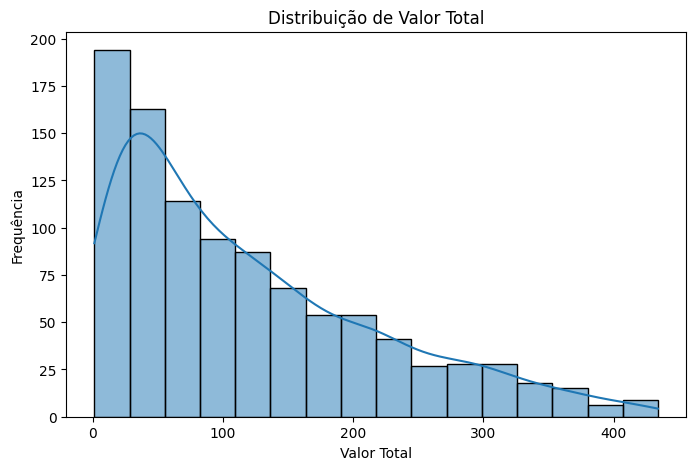

In [56]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Histograma com KDE
plt.figure(figsize=(8,5))
sns.histplot(df["valor_total"], kde=True)
plt.title("Distribuição de Valor Total")
plt.xlabel("Valor Total")
plt.ylabel("Frequência")
plt.show()


O QQ-Plot compara os quantis do valor total com os quantis de uma distribuição normal.

Observações:

os pontos se alinham à reta no centro → parte central lembra a normal;
porém, as extremidades se afastam da reta, principalmente no topo → cauda mais pesada que a normal;
há valores extremos (outliers naturais de compras grandes).

<Figure size 600x600 with 0 Axes>

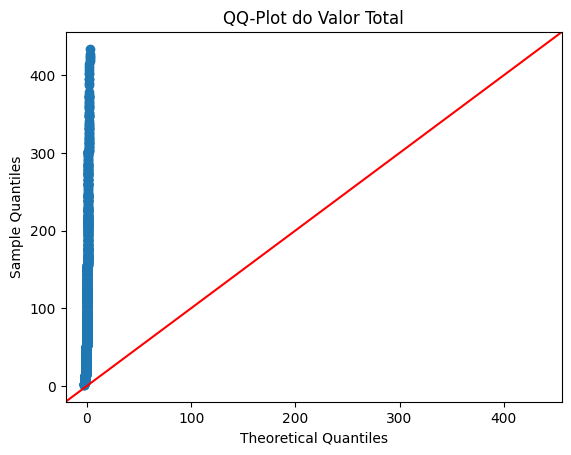

In [57]:
# QQ-Plot
plt.figure(figsize=(6,6))
sm.qqplot(df["valor_total"], line="45")
plt.title("QQ-Plot do Valor Total")
plt.show()

O comportamento da variável valor_total indica:

Assimetria positiva
Cauda longa
Ausência de normalidade
Adequação maior a modelos multiplicativos (log-normal)
Típico de dados de transações financeiras

Essa análise é útil porque mostra que testes estatísticos dependentes de normalidade (ex.: t-test clássico) não seriam adequados sem transformação, enquanto análises robustas são mais apropriadas.

###**Conclusão**

A análise exploratória realizada sobre a base de dados *sales.csv* permitiu compreender de forma abrangente o comportamento das vendas realizadas pelas filiais do supermercado em diferentes cidades. Foram examinadas variáveis relacionadas a clientes, produtos, preços, quantidades e desempenho das operações.

A análise univariada mostrou que as variáveis quantitativas apresentam padrões esperados para dados de transações comerciais: valores assimétricos, concentração em faixas inferiores e presença de caudas longas, especialmente no caso de **valor_total** e **imposto**, que são diretamente proporcionais. As variáveis qualitativas revelaram distribuição equilibrada entre filiais, cidades, gêneros e tipos de clientes, o que contribuiu para uma análise sem viés estrutural.

Na análise bivariada, observou-se uma relação clara entre **quantidade** e **valor_total**, evidenciando que o volume de itens adquiridos é o principal determinante do valor final da compra. A relação entre **preço unitário** e **valor_total** mostrou baixa associação, indicando que compras grandes podem envolver itens baratos e vice-versa. O imposto, por sua vez, demonstrou relação linear quase perfeita com o valor total, conforme esperado, por ser calculado proporcionalmente ao valor da compra.

As questões levantadas ao longo da investigação proporcionaram insights relevantes. Clientes do tipo **Member** tendem a gastar mais do que clientes **Normal**, categorias de produtos possuem preços médios bem distintos, e algumas cidades apresentam maior diversidade de produtos vendidos. Apesar disso, não foram identificadas diferenças significativas no valor gasto entre os gêneros, sugerindo que o comportamento de compra é bastante uniforme nesse aspecto.

A análise das distribuições de probabilidade reforçou que variáveis financeiras, como o valor total das compras, não seguem uma distribuição normal, apresentando assimetria positiva e caudas mais pesadas. Isso é típico de dados econômicos e deve ser considerado em análises estatísticas mais avançadas.

De modo geral, o estudo permitiu obter uma visão sólida do funcionamento das vendas, do perfil dos clientes e do comportamento por categorias e filiais. Os resultados obtidos fornecem subsídios relevantes para uma futura análise preditiva, para estratégias de marketing, definição de estoques e entendimento das dinâmicas de consumo.
